### This notebook extract newly generated molecules after the DORAnet run: 

In [18]:
import os
import glob
import pandas as pd
from pathlib import Path
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors
from rdkit import RDLogger
from collections import defaultdict

RDLogger.DisableLog('rdApp.*')

### Discover All Starter Directories

In [19]:
doranetOutputDir = "doranet_output"

helpersToExclude = {
    'O', 'O=O', '[H][H]', 'O=C=O', 'C=O', '[C-]#[O+]', 'Br', '[Br][Br]',
    'CO', 'C=C', 'O=S(O)O', 'N', 'O=S(=O)(O)O', 'O=NO', 'N#N',
    'O=[N+]([O-])O', 'NO', 'C#N', 'S', 'O=S=O', 'N#CO', '[H+]', 'OO',
    'Cl', 'I', 'O=C(O)O', 'O=P(O)(O)O', 'O=P(O)(O)OP(=O)(O)O', 'C',
    'CC', 'CC=O', 'CC(=O)O', 'CCC(=O)O'
}

print(f"Output directory: {doranetOutputDir}")
print(f"Number of helpers to exclude: {len(helpersToExclude)}")

Output directory: doranet_output
Number of helpers to exclude: 33


In [20]:
# Automatically find all starter directories
allStarterDirPaths = sorted(glob.glob(os.path.join(doranetOutputDir, "starter_*")))

print(f"Found {len(allStarterDirPaths)} starter directories")

# Find the molecules CSV file inside each directory
discoveredCsvFiles = []
directoriesWithMissingCsv = []

for starterDirPath in allStarterDirPaths:
    dirName = os.path.basename(starterDirPath)

    # Expected CSV file name matches directory name
    expectedCsvPath = os.path.join(starterDirPath, f"{dirName}_molecules.csv")

    if os.path.exists(expectedCsvPath):
        discoveredCsvFiles.append({
            'dirName': dirName,
            'dirPath': starterDirPath,
            'csvPath': expectedCsvPath,
            'starterNum': int(dirName.replace('starter_', ''))
        })
    else:
        # Try to find any molecules CSV in the directory as fallback
        fallbackCsvPaths = glob.glob(os.path.join(starterDirPath, "*_molecules.csv"))
        if fallbackCsvPaths:
            discoveredCsvFiles.append({
                'dirName': dirName,
                'dirPath': starterDirPath,
                'csvPath': fallbackCsvPaths[0],
                'starterNum': int(dirName.replace('starter_', ''))
            })
        else:
            directoriesWithMissingCsv.append(dirName)

# Sort by starter number
discoveredCsvFiles.sort(key=lambda x: x['starterNum'])

print(f"Found {len(discoveredCsvFiles)} CSV files containing DORAnet generated molecules")
if directoriesWithMissingCsv:
    print(f"Missing CSV in {len(directoriesWithMissingCsv)} directories: "
          f"{directoriesWithMissingCsv[:10]}...")

Found 2054 starter directories
Found 2054 CSV files containing DORAnet generated molecules


### Read All CSV Files into a DataFrame

In [21]:
# Read all CSV files and combine into one DataFrame
perStarterDataFrames = []
csvReadErrors = []

for fileInfo in discoveredCsvFiles:
    try:
        singleStarterMolecules = pd.read_csv(fileInfo['csvPath'])

        # Add source starter information
        singleStarterMolecules['SourceStarterNum'] = fileInfo['starterNum']
        singleStarterMolecules['SourceDirectory'] = fileInfo['dirName']

        perStarterDataFrames.append(singleStarterMolecules)

    except Exception as e:
        csvReadErrors.append({
            'dirName': fileInfo['dirName'],
            'csvPath': fileInfo['csvPath'],
            'error': str(e)
        })

# Concatenate all DataFrames
if perStarterDataFrames:
    allMoleculesWithDuplicates = pd.concat(perStarterDataFrames, ignore_index=True)
    print(f"Total rows read (with duplicates and helpers): {len(allMoleculesWithDuplicates)}")
    print(f"Columns: {list(allMoleculesWithDuplicates.columns)}")
    print(f"Unique SMILES (before cleaning): {allMoleculesWithDuplicates['SMILES'].nunique()}")
else:
    print("ERROR: No CSV files could be read!")

if csvReadErrors:
    print(f"\nFailed to read {len(csvReadErrors)} files:")
    for err in csvReadErrors[:5]:
        print(f"  {err['dirName']}: {err['error']}")

allMoleculesWithDuplicates

Total rows read (with duplicates and helpers): 1102411
Columns: ['SMILES', 'Is_Starter', 'MolFormula', 'MolWeight', 'NumHeavyAtoms', 'SourceStarterNum', 'SourceDirectory']
Unique SMILES (before cleaning): 651836


,SMILES,Is_Starter,MolFormula,MolWeight,NumHeavyAtoms,SourceStarterNum,SourceDirectory
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,C10H16N5O13P3,506.9957,31,0,starter_00000
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,C10H14N5O7P,347.0631,23,0,starter_00000
2,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,C27H33N9O15P2,785.1571,53,0,starter_00000
3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,C27H35N9O15P2,787.1728,53,0,starter_00000
4,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,C10H15N5O10P2,427.0294,27,0,starter_00000
...,...,...,...,...,...,...,...
1102406,C[C@H](N)CC1=C(O)C(=O)OC1=C[C@@H](C)CNC=O,False,C12H18N2O4,254.1267,18,2053,starter_02053
1102407,Cc1c(O)c2oc1=C[C@@H](C)CNC(=O)[C@H](C)N=2,False,C12H16N2O3,236.1161,17,2053,starter_02053
1102408,C[C@H](C=C1OC(=O)C2=C1CO2)CNC(O)[C@H](C)N,False,C12H18N2O4,254.1267,18,2053,starter_02053
1102409,CC1=C2O[C@](C)(N)C(O)NC[C@H](C)C=C1OC2=O,False,C12H18N2O4,254.1267,18,2053,starter_02053


### Remove HELPERS and Deduplicate

In [22]:
# Step 1: Remove helpers
allMoleculesWithoutHelpers = allMoleculesWithDuplicates[
    ~allMoleculesWithDuplicates['SMILES'].isin(helpersToExclude)
].copy()

helpersRemovedCount = len(allMoleculesWithDuplicates) - len(allMoleculesWithoutHelpers)
helpersKeptPercent = (len(allMoleculesWithoutHelpers) / len(allMoleculesWithDuplicates)) * 100
print(f"Step 1 - Removed {helpersRemovedCount} helper molecules")
print(f"Remaining molecules: {len(allMoleculesWithoutHelpers)} ({helpersKeptPercent:.2f}%)")

# Step 2: Aggregate source starters per unique SMILES
sourceStarterMapping = (
    allMoleculesWithoutHelpers
    .groupby('SMILES')['SourceStarterNum']
    .apply(lambda x: sorted(set(x)))
    .reset_index()
)
sourceStarterMapping.columns = ['SMILES', 'SourceStarterList']
sourceStarterMapping['NumSourceStarters'] = sourceStarterMapping['SourceStarterList'].apply(len)
sourceStarterMapping['SourceStarters'] = sourceStarterMapping['SourceStarterList'].apply(
    lambda x: ';'.join(map(str, x))
)

# Also aggregate source directories per unique SMILES
sourceDirectoryMapping = (
    allMoleculesWithoutHelpers
    .groupby('SMILES')['SourceDirectory']
    .apply(lambda x: ';'.join(sorted(set(x))))
    .reset_index()
)
sourceDirectoryMapping.columns = ['SMILES', 'SourceDirectories']

# Step 3: Deduplicate - keep first occurrence of each SMILES
uniqueMolecules = allMoleculesWithoutHelpers.drop_duplicates(
    subset='SMILES', keep='first'
).copy()

# Keep only desired columns
uniqueMolecules = uniqueMolecules[['SMILES', 'Is_Starter']].copy()

# Step 4: Merge aggregated source starter and directory information
uniqueMolecules = uniqueMolecules.merge(
    sourceStarterMapping[['SMILES', 'NumSourceStarters', 'SourceStarters']],
    on='SMILES',
    how='left'
)
uniqueMolecules = uniqueMolecules.merge(
    sourceDirectoryMapping,
    on='SMILES',
    how='left'
)

duplicatesRemovedCount = len(allMoleculesWithoutHelpers) - len(uniqueMolecules)
dedupeKeptPercent = (len(uniqueMolecules) / len(allMoleculesWithoutHelpers)) * 100
overallKeptPercent = (len(uniqueMolecules) / len(allMoleculesWithDuplicates)) * 100

print(f"Step 2 - Removed {duplicatesRemovedCount} duplicate molecular SMILES ({dedupeKeptPercent:.2f}%)")
print(f"Final unique molecules: {len(uniqueMolecules)} ({overallKeptPercent:.2f}% of original)")

uniqueMolecules = uniqueMolecules.drop(columns=['NumSourceStarters', 'SourceStarters'])
uniqueMolecules

Step 1 - Removed 34743 helper molecules
Remaining molecules: 1067668 (96.85%)
Step 2 - Removed 415856 duplicate molecular SMILES (61.05%)
Final unique molecules: 651812 (59.13% of original)


,SMILES,Is_Starter,SourceDirectories
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,starter_00000;starter_00001;starter_00002;star...
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,starter_00000;starter_00001;starter_00002;star...
2,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,starter_00000;starter_00001;starter_00002;star...
3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,starter_00000;starter_00001;starter_00002;star...
4,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,starter_00000;starter_00001;starter_00002;star...
...,...,...,...
651807,C[C@H](N)CC1=C(O)C(=O)OC1=C[C@@H](C)CNC=O,False,starter_02053
651808,Cc1c(O)c2oc1=C[C@@H](C)CNC(=O)[C@H](C)N=2,False,starter_02053
651809,C[C@H](C=C1OC(=O)C2=C1CO2)CNC(O)[C@H](C)N,False,starter_02053
651810,CC1=C2O[C@](C)(N)C(O)NC[C@H](C)C=C1OC2=O,False,starter_02053


In [27]:
from rdkit import Chem
from rdkit.Chem import Draw
from PIL import Image, ImageDraw, ImageFont
import numpy as np
import io

# Step 1: Remove helpers
allMoleculesWithoutHelpers = allMoleculesWithDuplicates[
    ~allMoleculesWithDuplicates['SMILES'].isin(helpersToExclude)
].copy()

helpersRemovedCount = len(allMoleculesWithDuplicates) - len(allMoleculesWithoutHelpers)
helpersKeptPercent = (len(allMoleculesWithoutHelpers) / len(allMoleculesWithDuplicates)) * 100
print(f"Step 1 - Removed {helpersRemovedCount} helper molecules")
print(f"Remaining molecules: {len(allMoleculesWithoutHelpers)} ({helpersKeptPercent:.2f}%)")

# Step 2: Aggregate source starters per unique SMILES
sourceStarterMapping = (
    allMoleculesWithoutHelpers
    .groupby('SMILES')['SourceStarterNum']
    .apply(lambda x: sorted(set(x)))
    .reset_index()
)
sourceStarterMapping.columns = ['SMILES', 'SourceStarterList']
sourceStarterMapping['NumSourceStarters'] = sourceStarterMapping['SourceStarterList'].apply(len)
sourceStarterMapping['SourceStarters'] = sourceStarterMapping['SourceStarterList'].apply(
    lambda x: ';'.join(map(str, x))
)

sourceDirectoryMapping = (
    allMoleculesWithoutHelpers
    .groupby('SMILES')['SourceDirectory']
    .apply(lambda x: ';'.join(sorted(set(x))))
    .reset_index()
)
sourceDirectoryMapping.columns = ['SMILES', 'SourceDirectories']

# Step 3: Deduplicate
uniqueMolecules = allMoleculesWithoutHelpers.drop_duplicates(
    subset='SMILES', keep='first'
).copy()
uniqueMolecules = uniqueMolecules[['SMILES', 'Is_Starter']].copy()

# Step 4: Merge aggregated information
uniqueMolecules = uniqueMolecules.merge(
    sourceStarterMapping[['SMILES', 'NumSourceStarters', 'SourceStarters']],
    on='SMILES', how='left'
)
uniqueMolecules = uniqueMolecules.merge(
    sourceDirectoryMapping, on='SMILES', how='left'
)

duplicatesRemovedCount = len(allMoleculesWithoutHelpers) - len(uniqueMolecules)
dedupeKeptPercent = (len(uniqueMolecules) / len(allMoleculesWithoutHelpers)) * 100
overallKeptPercent = (len(uniqueMolecules) / len(allMoleculesWithDuplicates)) * 100

print(f"Step 2 - Removed {duplicatesRemovedCount} duplicate molecular SMILES ({dedupeKeptPercent:.2f}%)")
print(f"Final unique molecules: {len(uniqueMolecules)} ({overallKeptPercent:.2f}% of original)")

uniqueMolecules = uniqueMolecules.drop(columns=['NumSourceStarters', 'SourceStarters'])

# ============================================================
# Step 5: Build starter -> generated molecules mapping
# ============================================================

# Separate starters and generated molecules
starterSmiles = uniqueMolecules[uniqueMolecules['Is_Starter'] == True]['SMILES'].tolist()
generatedMolecules = allMoleculesWithoutHelpers[
    allMoleculesWithoutHelpers['Is_Starter'] == False
].copy()

# Build mapping: starter num -> starter SMILES
starterNumToSmiles = (
    allMoleculesWithoutHelpers[allMoleculesWithoutHelpers['Is_Starter'] == True]
    .drop_duplicates(subset='SourceStarterNum')
    .set_index('SourceStarterNum')['SMILES']
    .to_dict()
)

# Build mapping: starter SMILES -> list of unique generated SMILES
starterToGeneratedMap = {}
for starterNum, starterSmi in starterNumToSmiles.items():
    genSmiles = (
        generatedMolecules[generatedMolecules['SourceStarterNum'] == starterNum]['SMILES']
        .unique()
        .tolist()
    )
    if genSmiles:
        starterToGeneratedMap[starterSmi] = genSmiles

print(f"\nStarters with generated molecules: {len(starterToGeneratedMap)}")

# ============================================================
# Step 6: Create GIF frames
# ============================================================

def smiles_to_image(smiles, img_size=(250, 250)):
    """Convert SMILES to a PIL image."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        img = Image.new('RGB', img_size, 'white')
        draw = ImageDraw.Draw(img)
        draw.text((10, img_size[1] // 2), "Invalid SMILES", fill='red')
        return img
    return Draw.MolToImage(mol, size=img_size)


def create_frame(starter_entries, frame_width=1600, row_height=300, mol_size=(250, 250)):
    """
    Create one GIF frame showing up to 3 starters, each with up to 2 generated molecules.
    starter_entries: list of tuples (starter_smiles, [gen_smiles_1, gen_smiles_2])
    """
    frame_height = row_height * len(starter_entries)
    frame = Image.new('RGB', (frame_width, frame_height), 'white')
    draw = ImageDraw.Draw(frame)

    try:
        font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 14)
        title_font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 16)
    except (IOError, OSError):
        font = ImageFont.load_default()
        title_font = font

    for row_idx, (starter_smi, gen_smiles_list) in enumerate(starter_entries):
        y_offset = row_idx * row_height
        padding = 20

        # Draw starter molecule on the left
        starter_img = smiles_to_image(starter_smi, mol_size)
        frame.paste(starter_img, (padding, y_offset + padding))
        draw.text(
            (padding, y_offset + padding + mol_size[1] + 5),
            "Starter PKS protein", fill='blue', font=title_font
        )

        # Draw arrow
        arrow_x_start = padding + mol_size[0] + 20
        arrow_x_end = arrow_x_start + 80
        arrow_y = y_offset + padding + mol_size[1] // 2

        draw.line([(arrow_x_start, arrow_y), (arrow_x_end, arrow_y)], fill='black', width=3)
        draw.polygon([
            (arrow_x_end, arrow_y - 10),
            (arrow_x_end + 15, arrow_y),
            (arrow_x_end, arrow_y + 10)
        ], fill='black')

        # Draw up to 2 generated molecules on the right
        gen_x_start = arrow_x_end + 40
        for gen_idx, gen_smi in enumerate(gen_smiles_list[:3]):
            gen_x = gen_x_start + gen_idx * (mol_size[0] + 40)
            gen_img = smiles_to_image(gen_smi, mol_size)
            frame.paste(gen_img, (gen_x, y_offset + padding))
            draw.text(
                (gen_x, y_offset + padding + mol_size[1] + 5),
                f"Generated {gen_idx + 1}", fill='green', font=font
            )

        # Draw separator line between rows
        if row_idx < len(starter_entries) - 1:
            sep_y = (row_idx + 1) * row_height
            draw.line([(0, sep_y), (frame_width, sep_y)], fill='gray', width=1)

    return frame


# Build frame data: 3 starters per frame, 2 generated molecules per starter per frame
allFrameData = []
starterList = list(starterToGeneratedMap.items())

for starter_smi, gen_list in starterList:
    genChunks = [gen_list[i:i + 2] for i in range(0, len(gen_list), 3)]
    for chunk in genChunks:
        allFrameData.append((starter_smi, chunk))

# Group into frames of 3 starters each
framesGrouped = [allFrameData[i:i + 3] for i in range(0, len(allFrameData), 3)]

print(f"Total frames available: {len(framesGrouped)}")

# Evenly sample 1000 frames
maxFrames = 100
if len(framesGrouped) > maxFrames:
    sampleIndices = np.linspace(0, len(framesGrouped) - 1, maxFrames, dtype=int)
    framesSampled = [framesGrouped[i] for i in sampleIndices]
else:
    framesSampled = framesGrouped

print(f"Frames to generate: {len(framesSampled)}")

# Create sampled frames
allFrameImages = []
for frame_idx, frameGroup in enumerate(framesSampled):
    frameImg = create_frame(frameGroup)
    allFrameImages.append(frameImg)
    if (frame_idx + 1) % 100 == 0:
        print(f"Generated frame {frame_idx + 1}/{len(framesSampled)}")

# Save as GIF
gifOutputPath = os.path.join(doranetOutputDir, "starter_to_generated_molecules.gif")

allFrameImages[0].save(
    gifOutputPath,
    save_all=True,
    append_images=allFrameImages[1:],
    duration=3000,
    loop=0
)

print(f"\nGIF saved to: {gifOutputPath}")
print(f"Total frames: {len(allFrameImages)}")

Step 1 - Removed 34743 helper molecules
Remaining molecules: 1067668 (96.85%)
Step 2 - Removed 415856 duplicate molecular SMILES (61.05%)
Final unique molecules: 651812 (59.13% of original)

Starters with generated molecules: 2054
Total frames available: 118630
Frames to generate: 100
Generated frame 100/100

GIF saved to: doranet_output/starter_to_generated_molecules.gif
Total frames: 100


### Check matches for Natural Product from public data bases via `SMILES`
 - NPAtlas: https://www.npatlas.org/download
 - COCONUT: https://coconut.naturalproducts.net/download

In [28]:
# Call NP databases
npDatabases = [
    ('../natural_products_data/NPAtlas_np_data.sdf', 'npatlas'),
    ('../natural_products_data/coconut_np_data.sdf', 'coconut')
]


# Step 1: Load all natural product SMILES from SDF databases
allNaturalProductSmiles = set()

for sdfPath, dbName in npDatabases:
    print(f"Loading {dbName} from: {sdfPath}")
    
    supplier = Chem.SDMolSupplier(sdfPath)
    validCount = 0
    invalidCount = 0
    
    for mol in supplier:
        if mol is not None:
            canonicalSmiles = Chem.MolToSmiles(mol)
            allNaturalProductSmiles.add(canonicalSmiles)
            validCount += 1
        else:
            invalidCount += 1
    
    print(f"  {dbName}: {validCount} valid molecules, {invalidCount} invalid/skipped")

print(f"\nTotal unique natural product SMILES across all databases: {len(allNaturalProductSmiles)}")


# Step 2: Canonicalize SMILES in uniqueMolecules for consistent matching
print("\nCanonicalizing SMILES in uniqueMolecules...")

def canonicalizeSmiles(smiles):
    """Convert SMILES to canonical form for consistent comparison."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        return Chem.MolToSmiles(mol)
    return smiles

uniqueMolecules['CanonicalSMILES'] = uniqueMolecules['SMILES'].apply(canonicalizeSmiles)


# Step 3: Check membership and create new DataFrame
uniqueMoleculesNP_SMILES = uniqueMolecules.copy()
uniqueMoleculesNP_SMILES['IsNaturalProduct'] = uniqueMoleculesNP_SMILES['CanonicalSMILES'].isin(allNaturalProductSmiles)

# Drop the temporary canonical column
uniqueMoleculesNP_SMILES = uniqueMoleculesNP_SMILES.drop(columns=['CanonicalSMILES'])


# Step 4: Summary
naturalProductCount = uniqueMoleculesNP_SMILES['IsNaturalProduct'].sum()
nonNaturalProductCount = len(uniqueMoleculesNP_SMILES) - naturalProductCount
naturalProductPercent = (naturalProductCount / len(uniqueMoleculesNP_SMILES)) * 100


print("\n Natural product matching summary:")
print(f"Total unique molecules checked: {len(uniqueMoleculesNP_SMILES)}")
print(f"Natural products found: {naturalProductCount} ({naturalProductPercent:.2f}%)")
print(f"Non-natural products: {nonNaturalProductCount} ({100 - naturalProductPercent:.2f}%)")


# Among starters vs generated
if 'Is_Starter' in uniqueMoleculesNP_SMILES.columns:
    startersNP = uniqueMoleculesNP_SMILES[uniqueMoleculesNP_SMILES['Is_Starter'] == True]
    generatedNP = uniqueMoleculesNP_SMILES[uniqueMoleculesNP_SMILES['Is_Starter'] == False]
    
    starterNPCount = startersNP['IsNaturalProduct'].sum()
    generatedNPCount = generatedNP['IsNaturalProduct'].sum()
    
    starterNPPercent = (starterNPCount / len(startersNP) * 100) if len(startersNP) > 0 else 0
    generatedNPPercent = (generatedNPCount / len(generatedNP) * 100) if len(generatedNP) > 0 else 0
    
    print(f"\nAmong starters: {starterNPCount}/{len(startersNP)} are NPs ({starterNPPercent:.2f}%)")
    print(f"Among generated: {generatedNPCount}/{len(generatedNP)} are NPs ({generatedNPPercent:.2f}%)")

uniqueMoleculesNP_SMILES

Loading npatlas from: ../natural_products_data/NPAtlas_np_data.sdf
  npatlas: 36454 valid molecules, 0 invalid/skipped
Loading coconut from: ../natural_products_data/coconut_np_data.sdf
  coconut: 715818 valid molecules, 0 invalid/skipped

Total unique natural product SMILES across all databases: 720603

Canonicalizing SMILES in uniqueMolecules...

 Natural product matching summary:
Total unique molecules checked: 651812
Natural products found: 244 (0.04%)
Non-natural products: 651568 (99.96%)

Among starters: 0/1343 are NPs (0.00%)
Among generated: 244/650469 are NPs (0.04%)


,SMILES,Is_Starter,SourceDirectories,InChIKey,IsNaturalProduct
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,starter_00000;starter_00001;starter_00002;star...,ZKHQWZAMYRWXGA-KQYNXXCUSA-N,True
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,starter_00000;starter_00001;starter_00002;star...,UDMBCSSLTHHNCD-KQYNXXCUSA-N,True
2,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,starter_00000;starter_00001;starter_00002;star...,VWWQXMAJTJZDQX-UYBVJOGSSA-N,True
3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,starter_00000;starter_00001;starter_00002;star...,YPZRHBJKEMOYQH-UYBVJOGSSA-N,True
4,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,starter_00000;starter_00001;starter_00002;star...,XTWYTFMLZFPYCI-KQYNXXCUSA-N,True
...,...,...,...,...,...
651807,C[C@H](N)CC1=C(O)C(=O)OC1=C[C@@H](C)CNC=O,False,starter_02053,CLWZQCKWHIRPON-SFYZADRCSA-N,False
651808,Cc1c(O)c2oc1=C[C@@H](C)CNC(=O)[C@H](C)N=2,False,starter_02053,ADOJKGZRJVHYAS-SVRRBLITSA-N,False
651809,C[C@H](C=C1OC(=O)C2=C1CO2)CNC(O)[C@H](C)N,False,starter_02053,NKKUQCPQNZSZNI-ZBRSCZCWSA-N,False
651810,CC1=C2O[C@](C)(N)C(O)NC[C@H](C)C=C1OC2=O,False,starter_02053,KHDKTTOBZLBEIL-LRMHLGCNSA-N,False


## Natural Product Matching via `InChIKey`

In [26]:
from rdkit.Chem.inchi import MolToInchi, InchiToInchiKey

# Step 1: Load all natural product InChIKeys from SDF databases
allNaturalProductInchiKeys = set()

for sdfPath, dbName in npDatabases:
    print(f"Loading {dbName} from: {sdfPath}")

    supplier = Chem.SDMolSupplier(sdfPath)
    validCount = 0
    invalidCount = 0

    for mol in supplier:
        if mol is not None:
            try:
                inchi = MolToInchi(mol)
                if inchi is not None:
                    inchiKey = InchiToInchiKey(inchi)
                    allNaturalProductInchiKeys.add(inchiKey)
                    validCount += 1
                else:
                    invalidCount += 1
            except:
                invalidCount += 1
        else:
            invalidCount += 1

    print(f"  {dbName}: {validCount} valid molecules, {invalidCount} invalid/skipped")

print(f"\nTotal unique natural product InChIKeys across all databases: {len(allNaturalProductInchiKeys)}")

# Step 2: Convert SMILES in uniqueMolecules to InChIKeys
print("\nConverting SMILES to InChIKeys in uniqueMolecules...")

def smilesToInchiKey(smiles):
    """Convert SMILES to InChIKey for robust structural comparison."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        try:
            inchi = MolToInchi(mol)
            if inchi is not None:
                return InchiToInchiKey(inchi)
        except:
            pass
    return None

uniqueMolecules['InChIKey'] = uniqueMolecules['SMILES'].apply(smilesToInchiKey)

inchiKeyFailedCount = uniqueMolecules['InChIKey'].isna().sum()
print(f"Successfully converted: {len(uniqueMolecules) - inchiKeyFailedCount}")
print(f"Failed to convert: {inchiKeyFailedCount}")


# Step 3: Check membership and create new DataFrame
uniqueMoleculesNP_InChI = uniqueMolecules.copy()
uniqueMoleculesNP_InChI['IsNaturalProduct'] = uniqueMoleculesNP_InChI['InChIKey'].isin(allNaturalProductInchiKeys)

# Drop the InChIKey column if you don't need it; keep it if you do
# uniqueMoleculesNP_InChI = uniqueMoleculesNP_InChI.drop(columns=['InChIKey'])


# Step 4: Summary
naturalProductCount = uniqueMoleculesNP_InChI['IsNaturalProduct'].sum()
nonNaturalProductCount = len(uniqueMoleculesNP_InChI) - naturalProductCount
naturalProductPercent = (naturalProductCount / len(uniqueMoleculesNP_InChI)) * 100

print("\n Natural product matching summary (InChIKey-based):")
print(f"Total unique molecules checked: {len(uniqueMoleculesNP_InChI)}")
print(f"Natural products found: {naturalProductCount} ({naturalProductPercent:.2f}%)")
print(f"Non-natural products: {nonNaturalProductCount} ({100 - naturalProductPercent:.2f}%)")

# Among starters vs generated
if 'Is_Starter' in uniqueMoleculesNP_InChI.columns:
    startersNP = uniqueMoleculesNP_InChI[uniqueMoleculesNP_InChI['Is_Starter'] == True]
    generatedNP = uniqueMoleculesNP_InChI[uniqueMoleculesNP_InChI['Is_Starter'] == False]

    starterNPCount = startersNP['IsNaturalProduct'].sum()
    generatedNPCount = generatedNP['IsNaturalProduct'].sum()

    starterNPPercent = (starterNPCount / len(startersNP) * 100) if len(startersNP) > 0 else 0
    generatedNPPercent = (generatedNPCount / len(generatedNP) * 100) if len(generatedNP) > 0 else 0

    print(f"\nAmong starters: {starterNPCount}/{len(startersNP)} are NPs ({starterNPPercent:.2f}%)")
    print(f"Among generated: {generatedNPCount}/{len(generatedNP)} are NPs ({generatedNPPercent:.2f}%)")

uniqueMoleculesNP_InChI

Loading npatlas from: ../natural_products_data/NPAtlas_np_data.sdf
  npatlas: 36454 valid molecules, 0 invalid/skipped
Loading coconut from: ../natural_products_data/coconut_np_data.sdf
  coconut: 715818 valid molecules, 0 invalid/skipped

Total unique natural product InChIKeys across all databases: 710225

Converting SMILES to InChIKeys in uniqueMolecules...
Successfully converted: 651806
Failed to convert: 6

 Natural product matching summary (InChIKey-based):
Total unique molecules checked: 651812
Natural products found: 246 (0.04%)
Non-natural products: 651566 (99.96%)

Among starters: 0/1343 are NPs (0.00%)
Among generated: 246/650469 are NPs (0.04%)


,SMILES,Is_Starter,SourceDirectories,CanonicalSMILES,InChIKey,IsNaturalProduct
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,starter_00000;starter_00001;starter_00002;star...,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,ZKHQWZAMYRWXGA-KQYNXXCUSA-N,True
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,starter_00000;starter_00001;starter_00002;star...,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,UDMBCSSLTHHNCD-KQYNXXCUSA-N,True
2,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,starter_00000;starter_00001;starter_00002;star...,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,VWWQXMAJTJZDQX-UYBVJOGSSA-N,True
3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,starter_00000;starter_00001;starter_00002;star...,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,YPZRHBJKEMOYQH-UYBVJOGSSA-N,True
4,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,starter_00000;starter_00001;starter_00002;star...,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,XTWYTFMLZFPYCI-KQYNXXCUSA-N,True
...,...,...,...,...,...,...
651807,C[C@H](N)CC1=C(O)C(=O)OC1=C[C@@H](C)CNC=O,False,starter_02053,C[C@H](N)CC1=C(O)C(=O)OC1=C[C@@H](C)CNC=O,CLWZQCKWHIRPON-SFYZADRCSA-N,False
651808,Cc1c(O)c2oc1=C[C@@H](C)CNC(=O)[C@H](C)N=2,False,starter_02053,Cc1c(O)c2oc1=C[C@@H](C)CNC(=O)[C@H](C)N=2,ADOJKGZRJVHYAS-SVRRBLITSA-N,False
651809,C[C@H](C=C1OC(=O)C2=C1CO2)CNC(O)[C@H](C)N,False,starter_02053,C[C@H](C=C1OC(=O)C2=C1CO2)CNC(O)[C@H](C)N,NKKUQCPQNZSZNI-ZBRSCZCWSA-N,False
651810,CC1=C2O[C@](C)(N)C(O)NC[C@H](C)C=C1OC2=O,False,starter_02053,CC1=C2O[C@](C)(N)C(O)NC[C@H](C)C=C1OC2=O,KHDKTTOBZLBEIL-LRMHLGCNSA-N,False


### Drug-Likeness Analysis of molecules present in `uniqueMoleculesNP_SMILES`

Drug-likeness is a qualitative assessment used in drug discovery to determine whether a molecule has physicochemical and structural properties consistent with orally active drugs. Molecules that satisfy drug-likeness criteria are more likely to exhibit favorable **absorption, distribution, metabolism, excretion, and toxicity (ADMET)** profiles.

In this analysis, each unique molecule is evaluated against **five widely used drug-likeness filters**:

### 1. Lipinski's Rule of Five (Ro5)
Proposed by **Christopher Lipinski (1997)**, this is the most well-known drug-likeness filter. It predicts poor absorption or permeation when **more than one** of the following conditions is violated:

- Molecular Weight ≤ 500 Da
- LogP ≤ 5
- Hydrogen Bond Donors (HBD) ≤ 5
- Hydrogen Bond Acceptors (HBA) ≤ 10

> **Reference:** Lipinski, C.A. et al. *Adv. Drug Deliv. Rev.* **23**, 3–25 (1997). [DOI:10.1016/S0169-409X(96)00423-1](https://doi.org/10.1016/S0169-409X(96)00423-1)

### 2. Veber's Rules
Proposed by **Veber et al. (2002)**, these rules focus on oral bioavailability based on molecular flexibility and polar surface area:

- Number of Rotatable Bonds ≤ 10
- Topological Polar Surface Area (TPSA) ≤ 140 Å²

> **Reference:** Veber, D.F. et al. *J. Med. Chem.* **45**, 2615–2623 (2002). [DOI:10.1021/jm020017n](https://doi.org/10.1021/jm020017n)

### 3. Ghose Filter
Proposed by **Ghose et al. (1999)**, this filter defines a drug-like chemical space using ranges for key properties:

- 160 ≤ Molecular Weight ≤ 480 Da
- −0.4 ≤ LogP ≤ 5.6
- 20 ≤ Number of Heavy Atoms ≤ 70
- 40 ≤ Molar Refractivity ≤ 130

> **Reference:** Ghose, A.K. et al. *J. Comb. Chem.* **1**, 55–68 (1999). [DOI:10.1021/cc9800071](https://doi.org/10.1021/cc9800071)

### 4. Egan Filter
Proposed by **Egan et al. (2000)**, this filter predicts passive intestinal absorption using a simple two-parameter model:

- LogP ≤ 5.88
- TPSA ≤ 131.6 Å²

> **Reference:** Egan, W.J. et al. *J. Med. Chem.* **43**, 3867–3877 (2000). [DOI:10.1021/jm000292e](https://doi.org/10.1021/jm000292e)

### 5. Muegge Filter
Proposed by **Muegge et al. (2001)**, this pharmacophore-based filter uses a broader set of criteria to identify drug-like molecules:

- 200 ≤ Molecular Weight ≤ 600 Da
- −2 ≤ LogP ≤ 5
- TPSA ≤ 150 Å²
- Number of Rings ≤ 7
- Hydrogen Bond Acceptors ≤ 10
- Hydrogen Bond Donors ≤ 5
- Number of Rotatable Bonds ≤ 15
- Number of Heavy Atoms ≥ 8

> **Reference:** Muegge, I. et al. *J. Med. Chem.* **44**, 1841–1846 (2001). [DOI:10.1021/jm015507e](https://doi.org/10.1021/jm015507e)

### Drug-Like Score

Each molecule receives a **DrugLikeScore** ranging from **0 to 5**, representing the number of filters it passes. A score of **5** indicates the molecule satisfies all five drug-likeness criteria, suggesting strong potential as an orally bioavailable drug candidate.

| DrugLikeScore | Interpretation |
|:---:|:---|
| 5 | Excellent drug-likeness — passes all filters |
| 4 | Strong drug-likeness — minor deviation in one filter |
| 3 | Moderate drug-likeness |
| 2 | Weak drug-likeness |
| 1 | Poor drug-likeness |
| 0 | Not drug-like by any standard filter |

### Molecular Properties Computed

| Property | Description | Used By |
|:---|:---|:---|
| Molecular Weight (MW) | Exact molecular weight in Daltons | Lipinski, Ghose, Muegge |
| LogP | Octanol-water partition coefficient (lipophilicity) | Lipinski, Ghose, Egan, Muegge |
| HBD | Number of hydrogen bond donors | Lipinski, Muegge |
| HBA | Number of hydrogen bond acceptors | Lipinski, Muegge |
| TPSA | Topological polar surface area (Å²) | Veber, Egan, Muegge |
| Rotatable Bonds | Number of rotatable bonds | Veber, Muegge |
| Heavy Atoms | Number of non-hydrogen atoms | Ghose, Muegge |
| Molar Refractivity | Measure of molecular polarizability | Ghose |
| Rings | Total number of rings | Muegge |
| Aromatic Rings | Number of aromatic rings | Structural characterization |

> **Note:** These filters are designed primarily for **orally active small molecules**. Natural products and biologics may legitimately violate some criteria while still being therapeutically relevant. The DrugLikeScore should be interpreted as a guide, not an absolute cutoff.

In [31]:
from rdkit.Chem import Descriptors, rdMolDescriptors, Lipinski



# Drug-likeness filter functions
def computeDrugLikeProperties(smiles):
    """Compute drug-likeness properties from SMILES."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return pd.Series({
            'MolWeight': None,
            'LogP': None,
            'NumHBD': None,
            'NumHBA': None,
            'TPSA': None,
            'NumRotatableBonds': None,
            'NumRings': None,
            'NumAromaticRings': None,
            'NumHeavyAtoms': None,
            'MolarRefractivity': None,
            'PassesLipinski': False,
            'LipinskiViolations': None,
            'PassesVeber': False,
            'PassesGhose': False,
            'PassesEgan': False,
            'PassesMuegge': False,
            'DrugLikeScore': 0,
            'IsValidMol': False
        })

    molWeight = Descriptors.ExactMolWt(mol)
    logP = Descriptors.MolLogP(mol)
    numHBD = rdMolDescriptors.CalcNumHBD(mol)
    numHBA = rdMolDescriptors.CalcNumHBA(mol)
    tpsa = rdMolDescriptors.CalcTPSA(mol)
    numRotatableBonds = rdMolDescriptors.CalcNumRotatableBonds(mol)
    numRings = rdMolDescriptors.CalcNumRings(mol)
    numAromaticRings = rdMolDescriptors.CalcNumAromaticRings(mol)
    numHeavyAtoms = mol.GetNumHeavyAtoms()
    molarRefractivity = Descriptors.MolMR(mol)

    # -----------------------------------------------------------------
    # Lipinski's Rule of Five
    # MW <= 500, LogP <= 5, HBD <= 5, HBA <= 10
    # Passes if at most 1 violation
    # -----------------------------------------------------------------
    lipinskiViolations = 0
    if molWeight > 500:
        lipinskiViolations += 1
    if logP > 5:
        lipinskiViolations += 1
    if numHBD > 5:
        lipinskiViolations += 1
    if numHBA > 10:
        lipinskiViolations += 1
    passesLipinski = lipinskiViolations <= 1

    # -----------------------------------------------------------------
    # Veber's Rules
    # RotatableBonds <= 10, TPSA <= 140
    # -----------------------------------------------------------------
    passesVeber = (numRotatableBonds <= 10) and (tpsa <= 140)

    # -----------------------------------------------------------------
    # Ghose Filter
    # 160 <= MW <= 480, -0.4 <= LogP <= 5.6,
    # 40 <= NumAtoms <= 480 (heavy atoms: 20 <= x <= 70),
    # 40 <= MolarRefractivity <= 130
    # -----------------------------------------------------------------
    passesGhose = (
        (160 <= molWeight <= 480) and
        (-0.4 <= logP <= 5.6) and
        (20 <= numHeavyAtoms <= 70) and
        (40 <= molarRefractivity <= 130)
    )

    # -----------------------------------------------------------------
    # Egan Filter
    # LogP <= 5.88, TPSA <= 131.6
    # -----------------------------------------------------------------
    passesEgan = (logP <= 5.88) and (tpsa <= 131.6)

    # -----------------------------------------------------------------
    # Muegge Filter
    # 200 <= MW <= 600, -2 <= LogP <= 5, TPSA <= 150,
    # NumRings <= 7, NumHBA <= 10, NumHBD <= 5,
    # NumRotatableBonds <= 15, NumHeavyAtoms >= 8
    # -----------------------------------------------------------------
    passesMuegge = (
        (200 <= molWeight <= 600) and
        (-2 <= logP <= 5) and
        (tpsa <= 150) and
        (numRings <= 7) and
        (numHBA <= 10) and
        (numHBD <= 5) and
        (numRotatableBonds <= 15) and
        (numHeavyAtoms >= 8)
    )

    # -----------------------------------------------------------------
    # DrugLikeScore: how many filters passed (0–5)
    # -----------------------------------------------------------------
    drugLikeScore = sum([
        passesLipinski,
        passesVeber,
        passesGhose,
        passesEgan,
        passesMuegge
    ])

    return pd.Series({
        'MolWeight': round(molWeight, 4),
        'LogP': round(logP, 4),
        'NumHBD': numHBD,
        'NumHBA': numHBA,
        'TPSA': round(tpsa, 2),
        'NumRotatableBonds': numRotatableBonds,
        'NumRings': numRings,
        'NumAromaticRings': numAromaticRings,
        'NumHeavyAtoms': numHeavyAtoms,
        'MolarRefractivity': round(molarRefractivity, 4),
        'PassesLipinski': passesLipinski,
        'LipinskiViolations': lipinskiViolations,
        'PassesVeber': passesVeber,
        'PassesGhose': passesGhose,
        'PassesEgan': passesEgan,
        'PassesMuegge': passesMuegge,
        'DrugLikeScore': drugLikeScore,
        'IsValidMol': True
    })



# Compute drug-likeness for all molecules
print(f"Computing drug-likeness properties for {len(uniqueMoleculesNP_SMILES)} molecules...")

drugLikeProperties = uniqueMoleculesNP_SMILES['SMILES'].apply(computeDrugLikeProperties)

uniqueMoleculesNP_SMILES_drug = pd.concat(
    [uniqueMoleculesNP_SMILES.reset_index(drop=True), drugLikeProperties],
    axis=1
)

invalidMolCount = len(uniqueMoleculesNP_SMILES_drug[~uniqueMoleculesNP_SMILES_drug['IsValidMol']])
print(f"Invalid molecules: {invalidMolCount}")
print(f"Final DataFrame shape: {uniqueMoleculesNP_SMILES_drug.shape}")


# Summary
validMols = uniqueMoleculesNP_SMILES_drug[uniqueMoleculesNP_SMILES_drug['IsValidMol']]
totalValid = len(validMols)

lipinskiCount = validMols['PassesLipinski'].sum()
veberCount = validMols['PassesVeber'].sum()
ghoseCount = validMols['PassesGhose'].sum()
eganCount = validMols['PassesEgan'].sum()
mueggeCount = validMols['PassesMuegge'].sum()
allFiveCount = len(validMols[validMols['DrugLikeScore'] == 5])
nonePassedCount = len(validMols[validMols['DrugLikeScore'] == 0])


print("Drug likeliness summary:")
print(f"Total valid molecules: {totalValid}")
print(f"  Passes Lipinski (Ro5):  {lipinskiCount} ({lipinskiCount/totalValid*100:.2f}%)")
print(f"  Passes Veber:           {veberCount} ({veberCount/totalValid*100:.2f}%)")
print(f"  Passes Ghose:           {ghoseCount} ({ghoseCount/totalValid*100:.2f}%)")
print(f"  Passes Egan:            {eganCount} ({eganCount/totalValid*100:.2f}%)")
print(f"  Passes Muegge:          {mueggeCount} ({mueggeCount/totalValid*100:.2f}%)")
print(f"\n  Passes ALL 5 filters:   {allFiveCount} ({allFiveCount/totalValid*100:.2f}%)")
print(f"  Passes NONE:            {nonePassedCount} ({nonePassedCount/totalValid*100:.2f}%)")

# DrugLikeScore distribution
print(f"\nDrugLikeScore Distribution:")
for score in range(6):
    count = len(validMols[validMols['DrugLikeScore'] == score])
    print(f"  Score {score}/5: {count} ({count/totalValid*100:.2f}%)")

# Breakdown: starters vs generated
if 'Is_Starter' in uniqueMoleculesNP_SMILES_drug.columns:
    startersDrug = validMols[validMols['Is_Starter'] == True]
    generatedDrug = validMols[validMols['Is_Starter'] == False]

    starterAllFive = len(startersDrug[startersDrug['DrugLikeScore'] == 5])
    generatedAllFive = len(generatedDrug[generatedDrug['DrugLikeScore'] == 5])

    starterPercent = (starterAllFive / len(startersDrug) * 100) if len(startersDrug) > 0 else 0
    generatedPercent = (generatedAllFive / len(generatedDrug) * 100) if len(generatedDrug) > 0 else 0

    print(f"\nAmong starters:  {starterAllFive}/{len(startersDrug)} pass all 5 ({starterPercent:.2f}%)")
    print(f"Among generated: {generatedAllFive}/{len(generatedDrug)} pass all 5 ({generatedPercent:.2f}%)")

# Breakdown: NP vs non-NP
if 'IsNaturalProduct' in uniqueMoleculesNP_SMILES_drug.columns:
    npDrug = validMols[validMols['IsNaturalProduct'] == True]
    nonNpDrug = validMols[validMols['IsNaturalProduct'] == False]

    npAllFive = len(npDrug[npDrug['DrugLikeScore'] == 5])
    nonNpAllFive = len(nonNpDrug[nonNpDrug['DrugLikeScore'] == 5])

    npPercent = (npAllFive / len(npDrug) * 100) if len(npDrug) > 0 else 0
    nonNpPercent = (nonNpAllFive / len(nonNpDrug) * 100) if len(nonNpDrug) > 0 else 0

    print(f"\nAmong NPs:       {npAllFive}/{len(npDrug)} pass all 5 ({npPercent:.2f}%)")
    print(f"Among non-NPs:   {nonNpAllFive}/{len(nonNpDrug)} pass all 5 ({nonNpPercent:.2f}%)")

uniqueMoleculesNP_SMILES_drug

Computing drug-likeness properties for 651812 molecules...
Invalid molecules: 0
Final DataFrame shape: (651812, 23)
Drug likeliness summary:
Total valid molecules: 651812
  Passes Lipinski (Ro5):  651799 (100.00%)
  Passes Veber:           642446 (98.56%)
  Passes Ghose:           1316 (0.20%)
  Passes Egan:            630056 (96.66%)
  Passes Muegge:          519111 (79.64%)

  Passes ALL 5 filters:   1205 (0.18%)
  Passes NONE:            13 (0.00%)

DrugLikeScore Distribution:
  Score 0/5: 13 (0.00%)
  Score 1/5: 8583 (1.32%)
  Score 2/5: 7265 (1.11%)
  Score 3/5: 123394 (18.93%)
  Score 4/5: 511352 (78.45%)
  Score 5/5: 1205 (0.18%)

Among starters:  361/1343 pass all 5 (26.88%)
Among generated: 844/650469 pass all 5 (0.13%)

Among NPs:       0/244 pass all 5 (0.00%)
Among non-NPs:   1205/651568 pass all 5 (0.18%)


,SMILES,Is_Starter,SourceDirectories,InChIKey,IsNaturalProduct,MolWeight,LogP,NumHBD,NumHBA,TPSA,...,NumHeavyAtoms,MolarRefractivity,PassesLipinski,LipinskiViolations,PassesVeber,PassesGhose,PassesEgan,PassesMuegge,DrugLikeScore,IsValidMol
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,starter_00000;starter_00001;starter_00002;star...,ZKHQWZAMYRWXGA-KQYNXXCUSA-N,True,506.9957,-1.6290,7,14,279.13,...,31,95.4757,False,3,False,False,False,False,0,True
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,starter_00000;starter_00001;starter_00002;star...,UDMBCSSLTHHNCD-KQYNXXCUSA-N,True,347.0631,-1.8630,5,10,186.07,...,23,73.6551,True,0,False,False,False,False,1,True
2,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,starter_00000;starter_00001;starter_00002;star...,VWWQXMAJTJZDQX-UYBVJOGSSA-N,True,785.1571,-2.4240,9,21,362.93,...,53,176.8337,False,3,False,False,False,False,0,True
3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,starter_00000;starter_00001;starter_00002;star...,YPZRHBJKEMOYQH-UYBVJOGSSA-N,True,787.1728,-1.7503,11,20,363.28,...,53,180.2071,False,3,False,False,False,False,0,True
4,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,starter_00000;starter_00001;starter_00002;star...,XTWYTFMLZFPYCI-KQYNXXCUSA-N,True,427.0294,-1.7460,6,12,232.60,...,27,84.5654,False,2,False,False,False,False,0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
651807,C[C@H](N)CC1=C(O)C(=O)OC1=C[C@@H](C)CNC=O,False,starter_02053,CLWZQCKWHIRPON-SFYZADRCSA-N,False,254.1267,0.3586,3,5,101.65,...,18,65.3269,True,0,True,False,True,True,4,True
651808,Cc1c(O)c2oc1=C[C@@H](C)CNC(=O)[C@H](C)N=2,False,starter_02053,ADOJKGZRJVHYAS-SVRRBLITSA-N,False,236.1161,-0.1519,2,4,74.83,...,17,61.9915,True,0,True,False,True,True,4,True
651809,C[C@H](C=C1OC(=O)C2=C1CO2)CNC(O)[C@H](C)N,False,starter_02053,NKKUQCPQNZSZNI-ZBRSCZCWSA-N,False,254.1267,-0.3973,3,6,93.81,...,18,63.9759,True,0,True,False,True,True,4,True
651810,CC1=C2O[C@](C)(N)C(O)NC[C@H](C)C=C1OC2=O,False,starter_02053,KHDKTTOBZLBEIL-LRMHLGCNSA-N,False,254.1267,-0.0497,3,6,93.81,...,18,63.7259,True,0,True,False,True,True,4,True


# How many pathways has been generated

In [11]:
import PyPDF2

# Automatically find all starter directories
allStarterDirPaths = sorted(glob.glob(os.path.join(doranetOutputDir, "starter_*")))

totalStarterDirs = len(allStarterDirPaths)
print(f"Found {totalStarterDirs} starter molecules")

# Count pathways from PDF files in each directory
pathwayCountsPerStarter = []

for starterDirPath in allStarterDirPaths:
    dirName = os.path.basename(starterDirPath)
    starterNum = int(dirName.replace('starter_', ''))

    expectedPdfPath = os.path.join(starterDirPath, f"{dirName}_pathways_visualized.pdf")

    if not os.path.exists(expectedPdfPath):
        fallbackPdfPaths = glob.glob(os.path.join(starterDirPath, "*_pathways_visualized.pdf"))
        expectedPdfPath = fallbackPdfPaths[0] if fallbackPdfPaths else None

    numPathways = 0
    if expectedPdfPath and os.path.exists(expectedPdfPath):
        try:
            with open(expectedPdfPath, 'rb') as pdfFile:
                pdfReader = PyPDF2.PdfReader(pdfFile)
                numPathways = len(pdfReader.pages)
        except Exception as e:
            print(f"Error reading PDF for {dirName}: {e}")

    pathwayCountsPerStarter.append({
        'StarterDirectory': dirName,
        'StarterNum': starterNum,
        'NumPathways': numPathways
    })

allPathwaysRaw = pd.DataFrame(pathwayCountsPerStarter).sort_values('StarterNum').reset_index(drop=True)

# Keep only starters with pathways
allPathways = allPathwaysRaw[allPathwaysRaw['NumPathways'] > 0].copy().reset_index(drop=True)

totalPathways = allPathways['NumPathways'].sum()
startersWithPathways = len(allPathways)
startersWithoutPathways = totalStarterDirs - startersWithPathways
withPercent = (startersWithPathways / totalStarterDirs) * 100
withoutPercent = (startersWithoutPathways / totalStarterDirs) * 100

print(f"Total pathways found: {totalPathways}")
print(f"Starters with pathways: {startersWithPathways} ({withPercent:.2f}%), "
      f"without: {startersWithoutPathways} ({withoutPercent:.2f}%)")

allPathways = allPathways.drop(columns=['StarterNum'])
allPathways

Found 2054 starter molecules
Total pathways found: 3011
Starters with pathways: 1458 (70.98%), without: 596 (29.02%)


,StarterDirectory,NumPathways
0,starter_00000,1
1,starter_00001,3
2,starter_00002,1
3,starter_00003,1
4,starter_00004,2
...,...,...
1453,starter_02048,1
1454,starter_02049,1
1455,starter_02051,4
1456,starter_02052,1


### Visualize pathways

In [1]:
import os, sys, shutil

doranetBin = os.path.dirname(sys.executable)  # .../doranet_env/bin
os.environ["PATH"] = doranetBin + ":" + os.environ.get("PATH", "")

# optional: align CONDA_PREFIX to the python you're actually using
os.environ["CONDA_PREFIX"] = os.path.dirname(doranetBin)

print("python:", sys.executable)
print("CONDA_PREFIX:", os.environ.get("CONDA_PREFIX"))
print("dot:", shutil.which("dot"))

from graphviz import Digraph

python: /users/sghosh6/.conda/envs/doranet_env/bin/python
CONDA_PREFIX: /users/sghosh6/.conda/envs/doranet_env
dot: /users/sghosh6/.conda/envs/doranet_env/bin/dot


Writing to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/doranet/scripts/RetroTide_basidalinPrecursor_set2/doranet_output/starter_00001/doranet_publication_figures

=== Rank 1 ===
Step PNG (rank 1, step 1): /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/doranet/scripts/RetroTide_basidalinPrecursor_set2/doranet_output/starter_00001/doranet_publication_figures/rank01_steps/rank01_step01.png (38445 bytes)


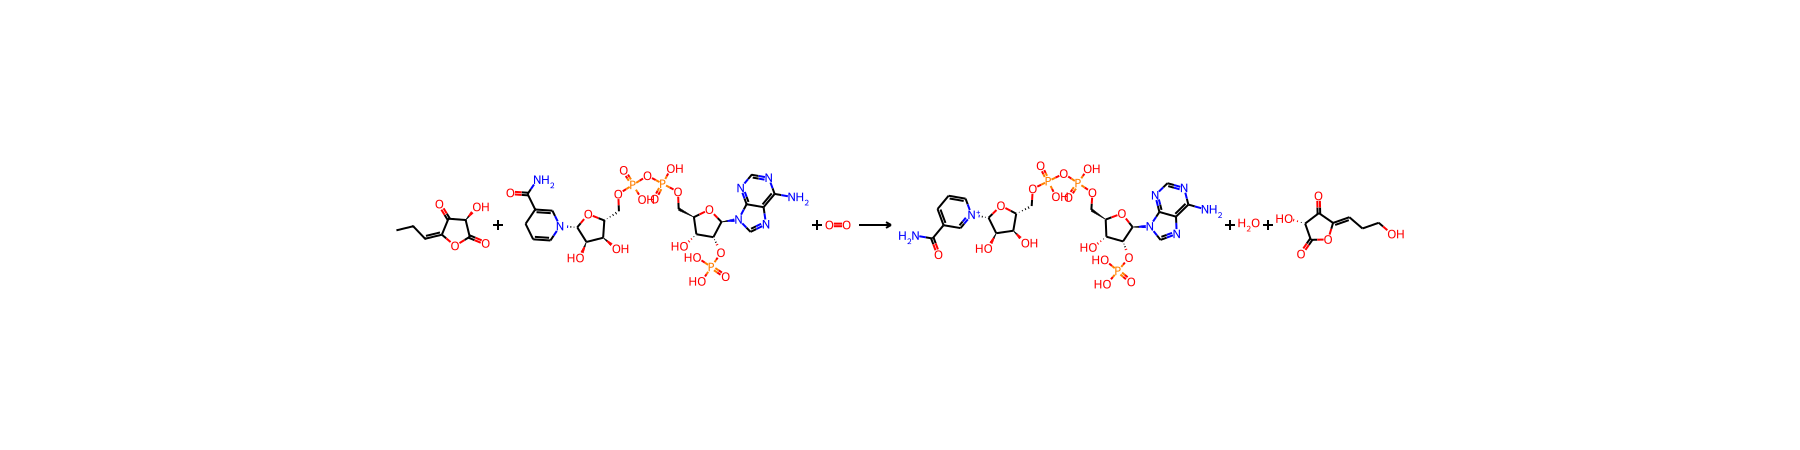

Step PNG (rank 1, step 2): /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/doranet/scripts/RetroTide_basidalinPrecursor_set2/doranet_output/starter_00001/doranet_publication_figures/rank01_steps/rank01_step02.png (36934 bytes)


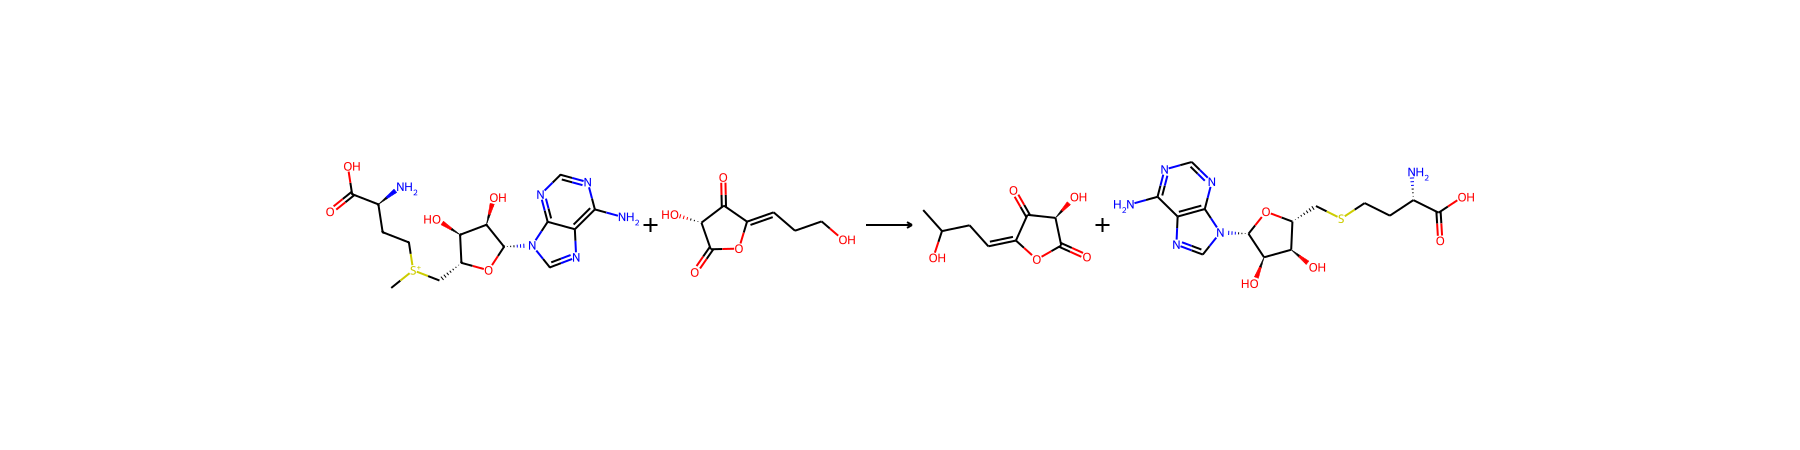

Pathway SVG (rank 1): /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/doranet/scripts/RetroTide_basidalinPrecursor_set2/doranet_output/starter_00001/doranet_publication_figures/pathway_rank01.svg (8194 bytes)


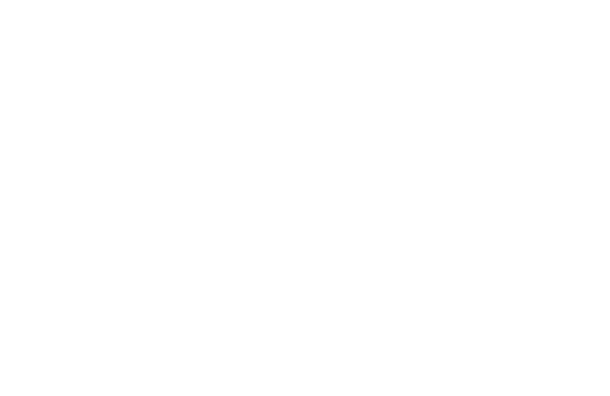

Pathway PNG (rank 1): /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/doranet/scripts/RetroTide_basidalinPrecursor_set2/doranet_output/starter_00001/doranet_publication_figures/pathway_rank01.png (280673 bytes)



=== Rank 2 ===
Step PNG (rank 2, step 1): /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/doranet/scripts/RetroTide_basidalinPrecursor_set2/doranet_output/starter_00001/doranet_publication_figures/rank02_steps/rank02_step01.png (45477 bytes)


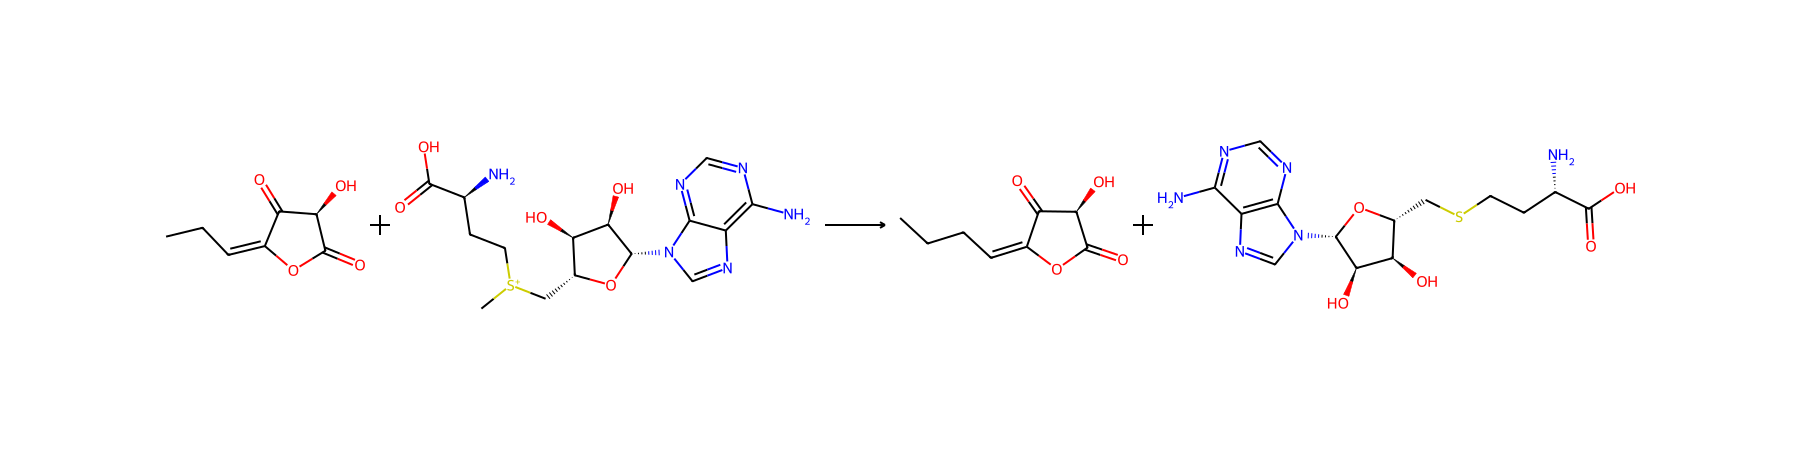

Step PNG (rank 2, step 2): /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/doranet/scripts/RetroTide_basidalinPrecursor_set2/doranet_output/starter_00001/doranet_publication_figures/rank02_steps/rank02_step02.png (38790 bytes)


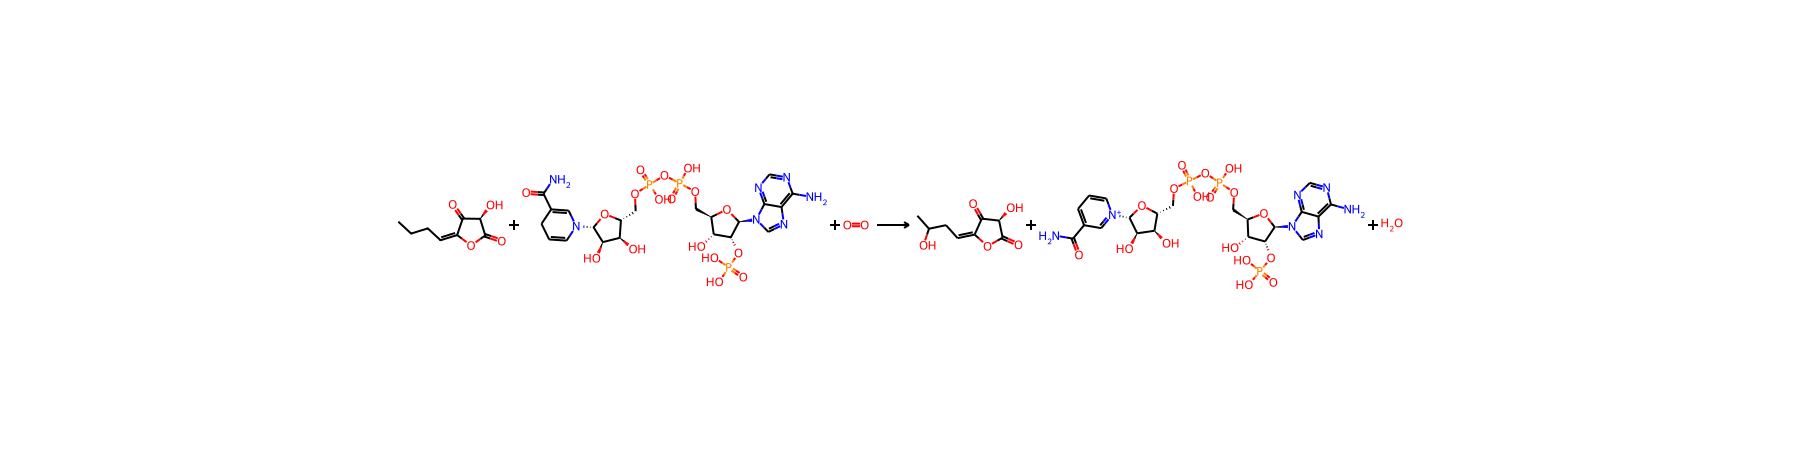

Pathway SVG (rank 2): /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/doranet/scripts/RetroTide_basidalinPrecursor_set2/doranet_output/starter_00001/doranet_publication_figures/pathway_rank02.svg (8113 bytes)


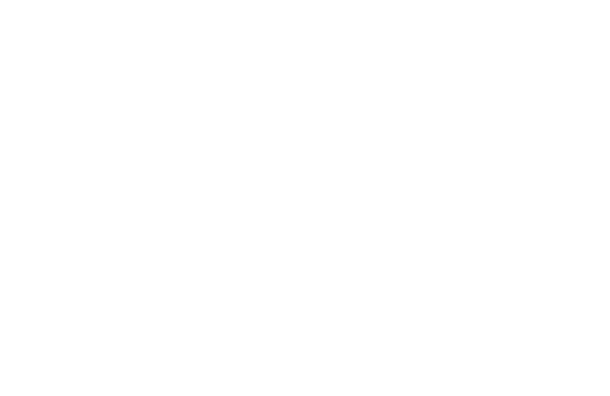

Pathway PNG (rank 2): /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/doranet/scripts/RetroTide_basidalinPrecursor_set2/doranet_output/starter_00001/doranet_publication_figures/pathway_rank02.png (280673 bytes)



=== Rank 3 ===
Step PNG (rank 3, step 1): /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/doranet/scripts/RetroTide_basidalinPrecursor_set2/doranet_output/starter_00001/doranet_publication_figures/rank03_steps/rank03_step01.png (23710 bytes)


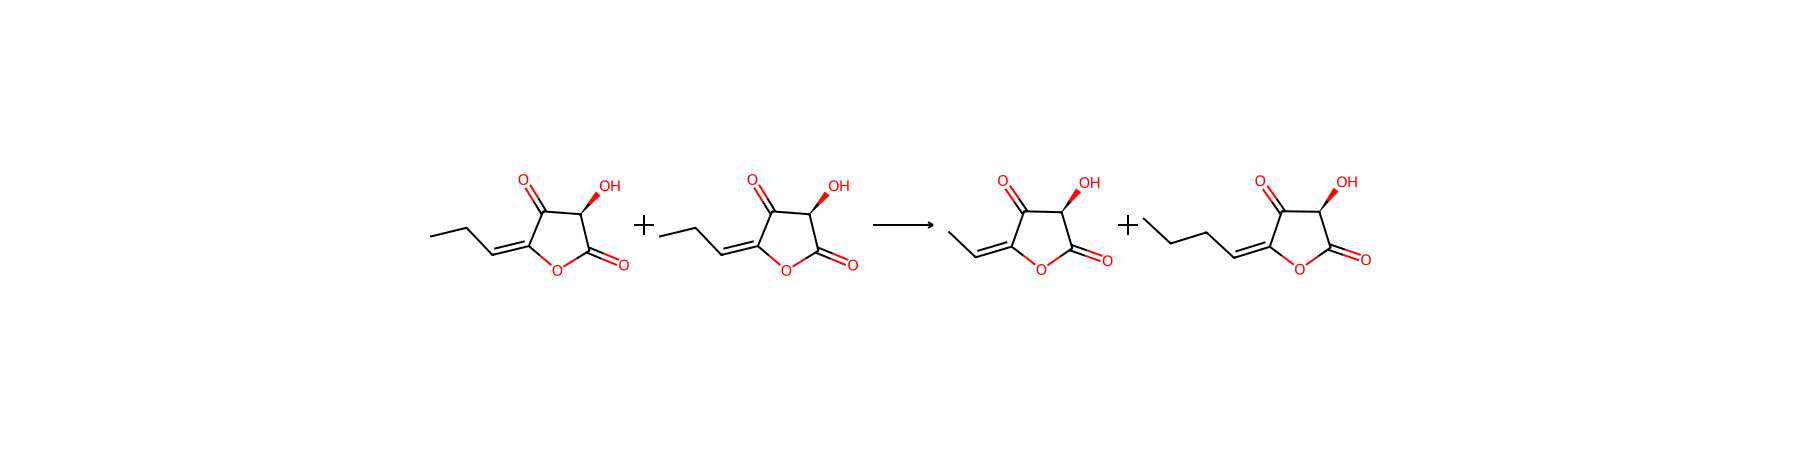

Step PNG (rank 3, step 2): /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/doranet/scripts/RetroTide_basidalinPrecursor_set2/doranet_output/starter_00001/doranet_publication_figures/rank03_steps/rank03_step02.png (38790 bytes)


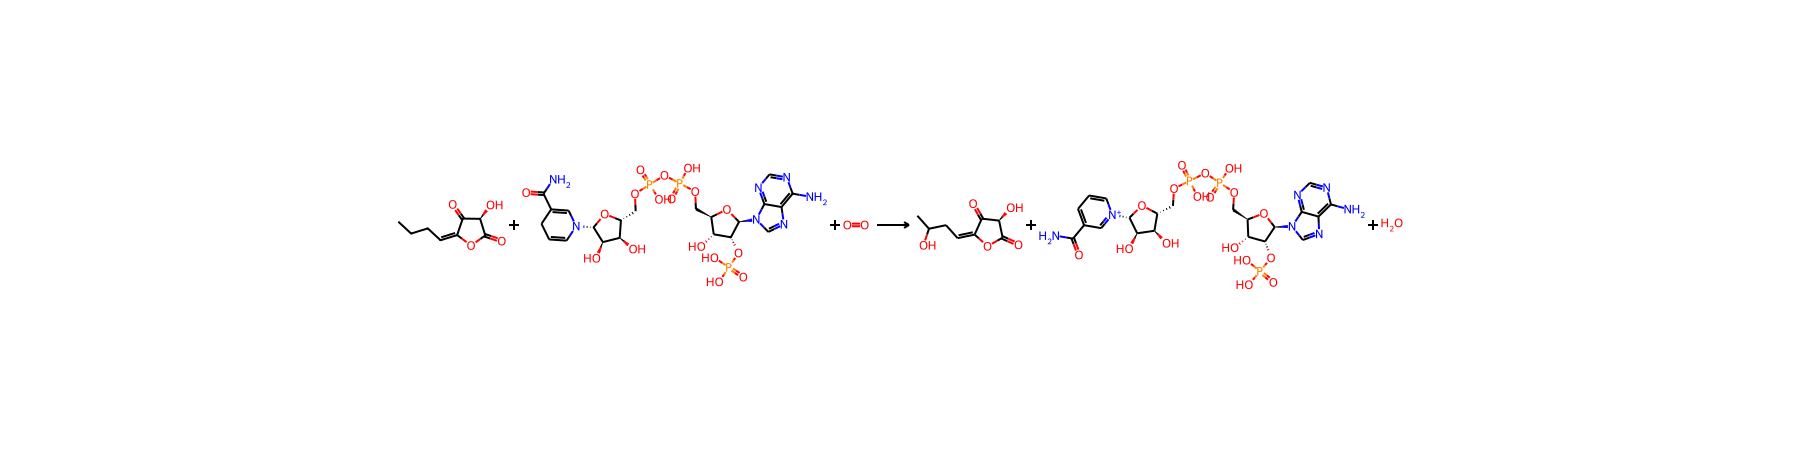

Pathway SVG (rank 3): /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/doranet/scripts/RetroTide_basidalinPrecursor_set2/doranet_output/starter_00001/doranet_publication_figures/pathway_rank03.svg (7737 bytes)


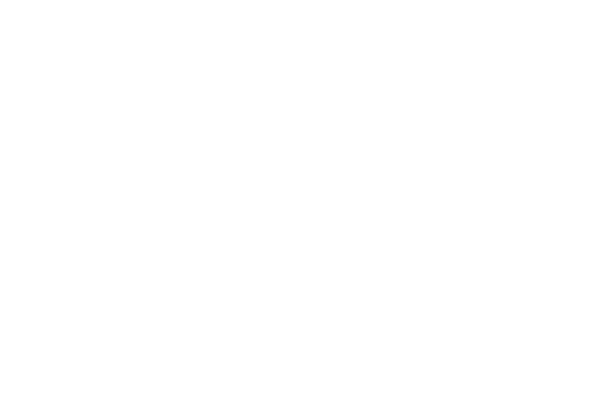

Pathway PNG (rank 3): /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/doranet/scripts/RetroTide_basidalinPrecursor_set2/doranet_output/starter_00001/doranet_publication_figures/pathway_rank03.png (278944 bytes)



Done.


In [3]:
import os
import re
import hashlib
from dataclasses import dataclass
from typing import Dict, List, Tuple

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem import rdChemReactions

from graphviz import Digraph

# notebook display
try:
    from IPython.display import display, SVG, Image as IPyImage
except Exception:
    display = None
    SVG = None
    IPyImage = None


@dataclass
class Pathway:
    rank: int
    finalScore: float
    atomicEconomy: float
    reactions: List[str]
    ruleNames: List[str]


def readTextFile(txtPath: str) -> str:
    with open(txtPath, "r", encoding="utf-8") as f:
        return f.read()


def parseRankedPathwayTxt(txt: str) -> List[Pathway]:
    blocks = re.split(r"\branking\s+", txt.strip())
    pathways: List[Pathway] = []

    for block in blocks:
        if not block.strip():
            continue

        rankMatch = re.match(r"(\d+)\s*", block)
        if not rankMatch:
            continue
        rank = int(rankMatch.group(1))

        def findFloat(pattern: str, default: float = float("nan")) -> float:
            m = re.search(pattern, block)
            return float(m.group(1)) if m else default

        finalScore = findFloat(r"final score\s+([0-9.]+)")
        atomicEconomy = findFloat(r"atomic economy\s+([0-9.]+)")

        reactionLines = []
        for line in block.splitlines():
            line = line.strip()
            if ">>" in line and not line.lower().startswith("reaction smiles"):
                reactionLines.append(line)

        ruleNames = [ln.strip() for ln in block.splitlines() if ln.strip().startswith("rule")]

        pathways.append(Pathway(rank, finalScore, atomicEconomy, reactionLines, ruleNames))

    pathways.sort(key=lambda p: p.rank)
    return pathways


def safeId(s: str) -> str:
    return hashlib.md5(s.encode("utf-8")).hexdigest()[:12]


def reactionFromSmiles(rxnSmiles: str) -> rdChemReactions.ChemicalReaction:
    return rdChemReactions.ReactionFromSmarts(rxnSmiles, useSmiles=True)


def drawReactionPng(rxnSmiles: str, outPath: str, width: int = 1800, height: int = 450) -> None:
    rxn = reactionFromSmiles(rxnSmiles)
    drawer = rdMolDraw2D.MolDraw2DCairo(width, height)
    opts = drawer.drawOptions()
    opts.fixedBondLength = 25
    opts.padding = 0.05
    drawer.DrawReaction(rxn)
    drawer.FinishDrawing()
    with open(outPath, "wb") as f:
        f.write(drawer.GetDrawingText())


def molPngFromSmiles(smiles: str, outPath: str, size: Tuple[int, int] = (420, 320)) -> None:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"Could not parse SMILES: {smiles}")
    Chem.rdDepictor.Compute2DCoords(mol)
    img = Draw.MolToImage(mol, size=size)
    img.save(outPath)


def splitReactionSmiles(rxnSmiles: str) -> Tuple[List[str], List[str]]:
    left, right = rxnSmiles.split(">>")
    reactants = [s for s in left.split(".") if s]
    products = [s for s in right.split(".") if s]
    return reactants, products


def requireNonEmpty(path: str, label: str) -> None:
    if not os.path.exists(path):
        raise FileNotFoundError(f"{label} was not created: {path}")
    size = os.path.getsize(path)
    if size == 0:
        raise RuntimeError(f"{label} is empty (0 bytes): {path}")
    print(f"{label}: {path} ({size} bytes)")


def buildPathwayGraphSvgBytes(
    pathway: Pathway,
    outDir: str,
    figureBaseName: str,
    graphDpi: int = 300
) -> Tuple[bytes, Dict[str, str]]:
    os.makedirs(outDir, exist_ok=True)
    nodeImgDir = os.path.join(outDir, f"{figureBaseName}_node_imgs")
    os.makedirs(nodeImgDir, exist_ok=True)

    g = Digraph(format="svg", engine="dot")
    g.attr(rankdir="LR", dpi=str(graphDpi))
    g.attr("node", fontname="Helvetica", fontsize="10")

    molImgCache: Dict[str, str] = {}

    def addMolNode(smiles: str) -> str:
        if smiles not in molImgCache:
            imgPath = os.path.abspath(os.path.join(nodeImgDir, f"mol_{safeId(smiles)}.png"))
            molPngFromSmiles(smiles, imgPath, size=(420, 320))
            molImgCache[smiles] = imgPath

        nodeId = f"mol_{safeId(smiles)}"
        # IMPORTANT: shape=none makes the image be the node; improves reliability for image nodes
        g.node(nodeId, label="", image=molImgCache[smiles], shape="none")
        return nodeId

    for stepIdx, rxnSmiles in enumerate(pathway.reactions, start=1):
        reactants, products = splitReactionSmiles(rxnSmiles)
        ruleLabel = pathway.ruleNames[stepIdx - 1] if stepIdx - 1 < len(pathway.ruleNames) else f"step{stepIdx}"

        stepNodeId = f"rxn_{pathway.rank}_{stepIdx}"
        g.node(stepNodeId, label=ruleLabel, shape="box")

        for rSmiles in reactants:
            rNode = addMolNode(rSmiles)
            g.edge(rNode, stepNodeId)

        for pSmiles in products:
            pNode = addMolNode(pSmiles)
            g.edge(stepNodeId, pNode)

    g.attr(
        label=f"Rank {pathway.rank} | score {pathway.finalScore:.2f} | atomic economy {pathway.atomicEconomy:.3f}",
        labelloc="t",
        fontsize="12"
    )

    # pipe() returns bytes directly (great for debugging; avoids silent render path issues)
    svgBytes = g.pipe(format="svg")
    return svgBytes, molImgCache


def svgBytesToPng(svgBytes: bytes, pngPath: str, scale: float = 2.0) -> None:
    import cairosvg
    cairosvg.svg2png(bytestring=svgBytes, write_to=pngPath, scale=scale)


def visualizeRankedPathwaysFromTxtPath(
    rankedPathwayTxtPath: str,
    outDir: str,
    writePerStepPanels: bool = True,
    graphDpi: int = 300,
    svgToPngScale: float = 2.0,
    showInline: bool = True
) -> None:
    txt = readTextFile(rankedPathwayTxtPath)
    pathways = parseRankedPathwayTxt(txt)
    os.makedirs(outDir, exist_ok=True)

    print("Writing to:", outDir)

    for p in pathways:
        print("\n=== Rank", p.rank, "===")

        # A) per-step reaction panels
        if writePerStepPanels:
            stepDir = os.path.join(outDir, f"rank{p.rank:02d}_steps")
            os.makedirs(stepDir, exist_ok=True)
            for i, rxnSmiles in enumerate(p.reactions, start=1):
                outPath = os.path.join(stepDir, f"rank{p.rank:02d}_step{i:02d}.png")
                drawReactionPng(rxnSmiles, outPath, width=1800, height=450)
                requireNonEmpty(outPath, f"Step PNG (rank {p.rank}, step {i})")

                if showInline and display and IPyImage:
                    display(IPyImage(filename=outPath))

        # B) pathway SVG via Graphviz pipe
        baseName = f"pathway_rank{p.rank:02d}"
        svgPath = os.path.join(outDir, f"{baseName}.svg")
        pngPath = os.path.join(outDir, f"{baseName}.png")

        svgBytes, molImgCache = buildPathwayGraphSvgBytes(
            p, outDir=outDir, figureBaseName=baseName, graphDpi=graphDpi
        )

        with open(svgPath, "wb") as f:
            f.write(svgBytes)
        requireNonEmpty(svgPath, f"Pathway SVG (rank {p.rank})")

        if showInline and display and SVG:
            display(SVG(data=svgBytes))

        # C) optional SVG -> PNG (requires CairoSVG)
        try:
            svgBytesToPng(svgBytes, pngPath, scale=svgToPngScale)
            requireNonEmpty(pngPath, f"Pathway PNG (rank {p.rank})")
            if showInline and display and IPyImage:
                display(IPyImage(filename=pngPath))
        except Exception as e:
            print(f"Skipping PNG conversion for rank {p.rank} (CairoSVG issue): {e}")

    print("\nDone.")



directoryPath = "/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/doranet/scripts"
rankedPathwayTxtPath = directoryPath + "/RetroTide_basidalinPrecursor_set2/doranet_output/starter_00001/starter_00001_ranked_pathways.txt"
visualizeRankedPathwaysFromTxtPath(
    rankedPathwayTxtPath,
    outDir=directoryPath + "/RetroTide_basidalinPrecursor_set2/doranet_output/starter_00001/doranet_publication_figures",
    writePerStepPanels=True,
    graphDpi=300,
    svgToPngScale=3.0,  # 2–4 is a good publication range
)

# Run `DORAnet` with Natural products as final product

### Discover All Starter Directories

In [9]:
doranetOutputDir_NP = "doranet_output_NP"

helpersToExclude = {
    'O', 'O=O', '[H][H]', 'O=C=O', 'C=O', '[C-]#[O+]', 'Br', '[Br][Br]',
    'CO', 'C=C', 'O=S(O)O', 'N', 'O=S(=O)(O)O', 'O=NO', 'N#N',
    'O=[N+]([O-])O', 'NO', 'C#N', 'S', 'O=S=O', 'N#CO', '[H+]', 'OO',
    'Cl', 'I', 'O=C(O)O', 'O=P(O)(O)O', 'O=P(O)(O)OP(=O)(O)O', 'C',
    'CC', 'CC=O', 'CC(=O)O', 'CCC(=O)O'
}

print(f"Output directory: {doranetOutputDir_NP}")
print(f"Number of helpers to exclude: {len(helpersToExclude)}")

Output directory: doranet_output_NP
Number of helpers to exclude: 33


In [10]:
# Automatically find all starter directories
allStarterDirPaths_NP = sorted(glob.glob(os.path.join(doranetOutputDir_NP, "starter_*_NP")))

print(f"Found {len(allStarterDirPaths_NP)} starter directories")

# Find the molecules CSV file inside each directory
discoveredCsvFiles = []
directoriesWithMissingCsv = []

for starterDirPath in allStarterDirPaths_NP:
    dirName = os.path.basename(starterDirPath)

    # Expected CSV file name matches directory name
    expectedCsvPath = os.path.join(starterDirPath, f"{dirName}_molecules.csv")

    if os.path.exists(expectedCsvPath):
        discoveredCsvFiles.append({
            'dirName': dirName,
            'dirPath': starterDirPath,
            'csvPath': expectedCsvPath,
            'starterNum': int(dirName.replace('starter_', '').replace('_NP', ''))
        })
    else:
        # Try to find any molecules CSV in the directory as fallback
        fallbackCsvPaths = glob.glob(os.path.join(starterDirPath, "*_molecules.csv"))
        if fallbackCsvPaths:
            discoveredCsvFiles.append({
                'dirName': dirName,
                'dirPath': starterDirPath,
                'csvPath': fallbackCsvPaths[0],
                'starterNum': int(dirName.replace('starter_', '').replace('_NP', ''))
            })
        else:
            directoriesWithMissingCsv.append(dirName)

# Sort by starter number
discoveredCsvFiles.sort(key=lambda x: x['starterNum'])

print(f"Found {len(discoveredCsvFiles)} CSV files containing DORAnet generated molecules")
if directoriesWithMissingCsv:
    print(f"Missing CSV in {len(directoriesWithMissingCsv)} directories: "
          f"{directoriesWithMissingCsv[:10]}...")

Found 2054 starter directories
Found 2054 CSV files containing DORAnet generated molecules


### Read All CSV Files into a DataFrame

In [11]:
# Read all CSV files and combine into one DataFrame
perStarterDataFrames = []
csvReadErrors = []

for fileInfo in discoveredCsvFiles:
    try:
        singleStarterMolecules = pd.read_csv(fileInfo['csvPath'])

        # Add source starter information
        singleStarterMolecules['SourceStarterNum'] = fileInfo['starterNum']
        singleStarterMolecules['SourceDirectory'] = fileInfo['dirName']

        perStarterDataFrames.append(singleStarterMolecules)

    except Exception as e:
        csvReadErrors.append({
            'dirName': fileInfo['dirName'],
            'csvPath': fileInfo['csvPath'],
            'error': str(e)
        })

# Concatenate all DataFrames
if perStarterDataFrames:
    allMoleculesWithDuplicates_wNP = pd.concat(perStarterDataFrames, ignore_index=True)
    print(f"Total rows read (with duplicates and helpers): {len(allMoleculesWithDuplicates_wNP)}")
    print(f"Columns: {list(allMoleculesWithDuplicates_wNP.columns)}")
    print(f"Unique SMILES (before cleaning): {allMoleculesWithDuplicates_wNP['SMILES'].nunique()}")
else:
    print("ERROR: No CSV files could be read!")

if csvReadErrors:
    print(f"\nFailed to read {len(csvReadErrors)} files:")
    for err in csvReadErrors[:5]:
        print(f"  {err['dirName']}: {err['error']}")

allMoleculesWithDuplicates_wNP

Total rows read (with duplicates and helpers): 1102411
Columns: ['SMILES', 'Is_Starter', 'Is_Helper', 'IsNaturalProduct', 'MolFormula', 'MolWeight', 'NumHeavyAtoms', 'InChIKey', 'SourceStarterNum', 'SourceDirectory']
Unique SMILES (before cleaning): 651836


,SMILES,Is_Starter,Is_Helper,IsNaturalProduct,MolFormula,MolWeight,NumHeavyAtoms,InChIKey,SourceStarterNum,SourceDirectory
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,False,True,C10H16N5O13P3,506.9957,31,ZKHQWZAMYRWXGA-KQYNXXCUSA-N,0,starter_00000_NP
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,False,True,C10H14N5O7P,347.0631,23,UDMBCSSLTHHNCD-KQYNXXCUSA-N,0,starter_00000_NP
2,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,False,True,C27H33N9O15P2,785.1571,53,VWWQXMAJTJZDQX-UYBVJOGSSA-N,0,starter_00000_NP
3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,False,True,C27H35N9O15P2,787.1728,53,YPZRHBJKEMOYQH-UYBVJOGSSA-N,0,starter_00000_NP
4,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,False,True,C10H15N5O10P2,427.0294,27,XTWYTFMLZFPYCI-KQYNXXCUSA-N,0,starter_00000_NP
...,...,...,...,...,...,...,...,...,...,...
1102406,C[C@H](N)CC1=C(O)C(=O)OC1=C[C@@H](C)CNC=O,False,False,False,C12H18N2O4,254.1267,18,CLWZQCKWHIRPON-SFYZADRCSA-N,2053,starter_02053_NP
1102407,Cc1c(O)c2oc1=C[C@@H](C)CNC(=O)[C@H](C)N=2,False,False,False,C12H16N2O3,236.1161,17,ADOJKGZRJVHYAS-SVRRBLITSA-N,2053,starter_02053_NP
1102408,C[C@H](C=C1OC(=O)C2=C1CO2)CNC(O)[C@H](C)N,False,False,False,C12H18N2O4,254.1267,18,NKKUQCPQNZSZNI-ZBRSCZCWSA-N,2053,starter_02053_NP
1102409,CC1=C2O[C@](C)(N)C(O)NC[C@H](C)C=C1OC2=O,False,False,False,C12H18N2O4,254.1267,18,KHDKTTOBZLBEIL-LRMHLGCNSA-N,2053,starter_02053_NP


### Remove HELPERS and Deduplicate

In [12]:
# Step 1: Remove helpers
allMoleculesWithoutHelpers = allMoleculesWithDuplicates_wNP[
    ~allMoleculesWithDuplicates_wNP['SMILES'].isin(helpersToExclude)
].copy()

helpersRemovedCount = len(allMoleculesWithDuplicates_wNP) - len(allMoleculesWithoutHelpers)
helpersKeptPercent = (len(allMoleculesWithoutHelpers) / len(allMoleculesWithDuplicates_wNP)) * 100
print(f"Step 1 - Removed {helpersRemovedCount} helper molecules")
print(f"Remaining molecules: {len(allMoleculesWithoutHelpers)} ({helpersKeptPercent:.2f}%)")

# Step 2: Aggregate source starters per unique SMILES
sourceStarterMapping = (
    allMoleculesWithoutHelpers
    .groupby('SMILES')['SourceStarterNum']
    .apply(lambda x: sorted(set(x)))
    .reset_index()
)
sourceStarterMapping.columns = ['SMILES', 'SourceStarterList']
sourceStarterMapping['NumSourceStarters'] = sourceStarterMapping['SourceStarterList'].apply(len)
sourceStarterMapping['SourceStarters'] = sourceStarterMapping['SourceStarterList'].apply(
    lambda x: ';'.join(map(str, x))
)

# Also aggregate source directories per unique SMILES
sourceDirectoryMapping = (
    allMoleculesWithoutHelpers
    .groupby('SMILES')['SourceDirectory']
    .apply(lambda x: ';'.join(sorted(set(x))))
    .reset_index()
)
sourceDirectoryMapping.columns = ['SMILES', 'SourceDirectories']

# Step 3: Deduplicate - keep first occurrence of each SMILES
uniqueMolecules_wNP = allMoleculesWithoutHelpers.drop_duplicates(
    subset='SMILES', keep='first'
).copy()

# Keep only desired columns
uniqueMolecules_wNP = uniqueMolecules_wNP[['SMILES', 'Is_Starter']].copy()

# Step 4: Merge aggregated source starter and directory information
uniqueMolecules_wNP = uniqueMolecules_wNP.merge(
    sourceStarterMapping[['SMILES', 'NumSourceStarters', 'SourceStarters']],
    on='SMILES',
    how='left'
)
uniqueMolecules_wNP = uniqueMolecules_wNP.merge(
    sourceDirectoryMapping,
    on='SMILES',
    how='left'
)

duplicatesRemovedCount = len(allMoleculesWithoutHelpers) - len(uniqueMolecules_wNP)
dedupeKeptPercent = (len(uniqueMolecules_wNP) / len(allMoleculesWithoutHelpers)) * 100
overallKeptPercent = (len(uniqueMolecules_wNP) / len(allMoleculesWithDuplicates_wNP)) * 100

print(f"Step 2 - Removed {duplicatesRemovedCount} duplicate molecular SMILES ({dedupeKeptPercent:.2f}%)")
print(f"Final unique molecules: {len(uniqueMolecules_wNP)} ({overallKeptPercent:.2f}% of original)")

uniqueMolecules_wNP = uniqueMolecules_wNP.drop(columns=['NumSourceStarters', 'SourceStarters'])
uniqueMolecules_wNP

Step 1 - Removed 34743 helper molecules
Remaining molecules: 1067668 (96.85%)
Step 2 - Removed 415856 duplicate molecular SMILES (61.05%)
Final unique molecules: 651812 (59.13% of original)


,SMILES,Is_Starter,SourceDirectories
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,starter_00000_NP;starter_00001_NP;starter_0000...
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,starter_00000_NP;starter_00001_NP;starter_0000...
2,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,starter_00000_NP;starter_00001_NP;starter_0000...
3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,starter_00000_NP;starter_00001_NP;starter_0000...
4,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,starter_00000_NP;starter_00001_NP;starter_0000...
...,...,...,...
651807,C[C@H](N)CC1=C(O)C(=O)OC1=C[C@@H](C)CNC=O,False,starter_02053_NP
651808,Cc1c(O)c2oc1=C[C@@H](C)CNC(=O)[C@H](C)N=2,False,starter_02053_NP
651809,C[C@H](C=C1OC(=O)C2=C1CO2)CNC(O)[C@H](C)N,False,starter_02053_NP
651810,CC1=C2O[C@](C)(N)C(O)NC[C@H](C)C=C1OC2=O,False,starter_02053_NP


### How many pathways has been generated 

In [16]:
import PyPDF2

# Count pathways from PDF files in each directory
pathwayCountsPerStarter = []

for starterDirPath in allStarterDirPaths_NP:
    dirName = os.path.basename(starterDirPath)
    starterNum = int(dirName.replace('starter_', '').replace('_NP', ''))

    expectedPdfPath = os.path.join(starterDirPath, f"{dirName}_pathways_visualized.pdf")

    if not os.path.exists(expectedPdfPath):
        fallbackPdfPaths = glob.glob(os.path.join(starterDirPath, "*_pathways_visualized.pdf"))
        expectedPdfPath = fallbackPdfPaths[0] if fallbackPdfPaths else None

    numPathways = 0
    if expectedPdfPath and os.path.exists(expectedPdfPath):
        try:
            with open(expectedPdfPath, 'rb') as pdfFile:
                pdfReader = PyPDF2.PdfReader(pdfFile)
                numPathways = len(pdfReader.pages)
        except Exception as e:
            print(f"Error reading PDF for {dirName}: {e}")

    pathwayCountsPerStarter.append({
        'StarterDirectory': dirName,
        'StarterNum': starterNum,
        'NumPathways': numPathways
    })

allPathways_wNPRaw = pd.DataFrame(pathwayCountsPerStarter).sort_values('StarterNum').reset_index(drop=True)

# Keep only starters with pathways
allPathways_wNP = allPathways_wNPRaw[allPathways_wNPRaw['NumPathways'] > 0].copy().reset_index(drop=True)

totalStarterDirs_NP = len(allStarterDirPaths_NP)
totalPathways = allPathways_wNP['NumPathways'].sum()
startersWithPathways = len(allPathways_wNP)
startersWithoutPathways = totalStarterDirs_NP - startersWithPathways
withPercent = (startersWithPathways / totalStarterDirs_NP) * 100
withoutPercent = (startersWithoutPathways / totalStarterDirs_NP) * 100

print(f"Total pathways found: {totalPathways}")
print(f"Starters with pathways: {startersWithPathways} ({withPercent:.2f}%), "
      f"without: {startersWithoutPathways} ({withoutPercent:.2f}%)")

allPathways_wNP = allPathways_wNP.drop(columns=['StarterNum'])
allPathways_wNP

Total pathways found: 1012
Starters with pathways: 500 (24.34%), without: 1554 (75.66%)


,StarterDirectory,NumPathways
0,starter_00000_NP,1
1,starter_00001_NP,1
2,starter_00004_NP,1
3,starter_00005_NP,1
4,starter_00006_NP,6
...,...,...
495,starter_02024_NP,4
496,starter_02031_NP,4
497,starter_02035_NP,4
498,starter_02041_NP,4
